In [4]:
import os
import tifffile
import numpy as np
import cv2
%matplotlib inline
from matplotlib import pyplot as plt
from math import sqrt, ceil, hypot
from skimage import feature
from skimage.filters import threshold_otsu, gaussian
from scipy.ndimage.morphology import binary_fill_holes
from scipy import interpolate

In [5]:
filepath='/Users/christina.bukas/Documents/AI_projects/datasets/NMOs/Contraction_videos/dev'
files = [file for file in os.listdir(filepath) if file.endswith('.tif')]
print('Dataset includes ', len(files), ' videos')

15 videos


## All videos have the same size in pixels but varying lengths

In [6]:
for file in files:
    img=tifffile.imread(os.path.join(filepath, file))
    print('File: ', file, 'Shape: ', img.shape)

Shape:  (1208, 256, 256)
Shape:  (796, 256, 256)
Shape:  (1208, 256, 256)
Shape:  (1813, 256, 256)
Shape:  (1813, 256, 256)
Shape:  (1208, 256, 256)
Shape:  (1208, 256, 256)
Shape:  (1208, 256, 256)
Shape:  (1509, 256, 256)
Shape:  (1813, 256, 256)
Shape:  (1208, 256, 256)
Shape:  (1813, 256, 256)
Shape:  (1813, 256, 256)
Shape:  (1208, 256, 256)
Shape:  (1208, 256, 256)


# Useful functions

In [189]:
def extract_border(img_slice):
    img_smooth = gaussian(img_slice, 2)
    thresh = threshold_otsu(img_smooth)
    image_thresh = img_smooth > thresh
    image_thresh = (1 - binary_fill_holes(1-image_thresh)).astype(bool)
    edges = feature.canny(image_thresh, 3) #sigma = 3 Standard deviation of the Gaussian filter.
    x, y = np.where(edges)
    return (x,y)


def remove_border_points(border_points):
    border_x = list(border_points[0])
    border_y = list(border_points[1])
    i = 0
    remove_ids = []
    for x, y in zip(border_x, border_y):
        if x<10 or x>245 or y<10 or y>245: remove_ids.append(i)
        i+=1
    for i in reversed(remove_ids):
        border_x.pop(i)
        border_y.pop(i)
    return (np.array(border_x), np.array(border_y))
   
    
def convert_vid2rgb(vid):
    vid_color = np.zeros((vid.shape[0], vid.shape[1], vid.shape[2], 3))
    for i in range(vid.shape[0]):
        frame = vid[i,:,:]
        vid_color[i] = cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)
    return vid_color.astype(np.uint8)


def get_normals(border_points, track_points, length, img_size):
    border_points = np.asarray(border_points).T
    track_points = np.asarray(track_points).T
    static_points_x = []
    static_points_y = []
    for point in track_points: 
        idx=np.where(np.all(point==border_points, axis=1))[0][0]
        if idx==border_points.shape[0]-1:
            x0, y0, xa, ya = point[0], point[1], border_points[idx-1, 0], border_points[idx-1, 1] 
            dx, dy = x0-xa, y0-ya
        else:
            x0, y0, xa, ya = point[0], point[1], border_points[idx+1, 0], border_points[idx+1, 1]
            dx, dy = xa-x0, ya-y0
        norm = hypot(dx, dy) * 1/length
        dx /= norm
        dy /= norm
        dx0 = max(0, min(x0-dy, img_size))
        dy0 = max(0, min(y0+dx, img_size))
        #plt.plot((x0, dx0), (y0, dy0))    # plot the normals
        static_points_x.append(dx0)
        static_points_y.append(dy0)
    return (static_points_x, static_points_y)
        

def get_tracking_points(frame0, num_track_points=10, static_distance=-30):
    # get the organoid border and remove image border pixels
    border_points = extract_border(frame0)
    border_points = remove_border_points(border_points)
    # sample points on border of organoid - select num_points points to track
    num_border_points = border_points[0].shape[0]
    idx = np.round(np.linspace(0, num_border_points - 1, num_track_points)).astype(int)
    track_points = (border_points[0][idx], border_points[1][idx])
    static_points = get_normals(border_points, track_points, length=static_distance, img_size=frame0.shape[1])
    
    return border_points, track_points, static_points


# https://www.geeksforgeeks.org/python-opencv-optical-flow-with-lucas-kanade-method/
def track_points_in_vid(vid, track_points, static_points, view=False, wait=100):
    
    # convert video to rgb format
    vid_color = convert_vid2rgb(vid)

    # params for corner detection
    feature_params = dict( maxCorners = 100,
                           qualityLevel = 0.3,
                           minDistance = 7,
                           blockSize = 7 )

    # Parameters for lucas kanade optical flow
    lk_params = dict( winSize = (15, 15),
                      maxLevel = 2,
                      criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

    # Take first frame and convert points from tuples to arrays
    old_gray = vid[0].copy() #cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
    track_points = np.asarray(track_points).T
    track_points = track_points[:, np.newaxis, :].astype(np.float32) # shape is (10,1,2) for 10 points to track
    static_points = np.asarray(static_points).T
    static_points = static_points[:, np.newaxis, :].astype(np.float32)
    
    tracked_points_vid = np.zeros((track_points.shape[0], vid.shape[0])) #, 2
    #tracked_points_vid[:, 0, :] = track_points[:, 0, :]
    tracked_points_vid[:, 0] = (track_points[:, 0, 0] - static_points[:, 0, 0])**2 + (track_points[:, 0, 1] - static_points[:, 0, 1])**2

    final_tracked_points_vid = tracked_points_vid.copy()
    original_ids = np.arange(10)
    points_lost = 0
    
    for frame_id in range(1, vid.shape[0]):   
        
        #if frame_id%500==0: print('Processing frame: ', frame_id)
        if view: frame = vid_color[frame_id] #.copy()
        frame_gray = vid[frame_id]
        
        # calculate optical flow
        tracked_points, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, track_points, None, **lk_params)
        # Select good points
        good_ids, _ = np.where(st==1)
        bad_ids, _ = np.where(st==0)
        
        if len(bad_ids)!=0:
            original_ids_final = original_ids[bad_ids]                
            final_tracked_points_vid[original_ids_final, :] = tracked_points_vid[original_ids_final, :]
            original_ids = np.delete(original_ids, bad_ids, 0)

        good_new_points = tracked_points[st == 1]
        static_points = static_points[st==1]
        #tracked_points_vid[original_ids, frame_id, :] = good_new_points
        tracked_points_vid[original_ids, frame_id] = (good_new_points[:,0] - static_points[:,0])**2 + (good_new_points[:,1] - static_points[:,1])**2

        # draw the tracks
        for i, (new_point, static_point) in enumerate(zip(good_new_points, static_points)):
            new_x, new_y = new_point.ravel()
            static_x, static_y = static_point.ravel()
            if view:
                frame = cv2.circle(frame, (new_y, new_x), 5, (0, 255, 0), -1) # add tracked point
                frame = cv2.circle(frame, (static_y, static_x), radius=5, color=(0, 255, 0), thickness=-1)
                frame = cv2.line(frame, (static_y, static_x), (new_y, new_x), (0, 0, 255), thickness=2)
            distance = sqrt(((static_x - new_x)**2 + (static_y - new_y)**2))
            
        if view:
            cv2.imshow('contraction', frame)
            k = cv2.waitKey(wait)
            if k == 27:
                break

        # Updating previous frame and points 
        old_gray = frame_gray.copy()
        track_points = good_new_points.reshape(-1, 1, 2)
        static_points = static_points[:, np.newaxis, :]
    final_tracked_points_vid[original_ids, :] = tracked_points_vid[original_ids, :]
    points_lost = final_tracked_points_vid.shape[0] - original_ids.shape[0]
    
    if view: cv2.destroyAllWindows()
    return final_tracked_points_vid, points_lost

## Extract the organoid border from videos and visualize a couple of results

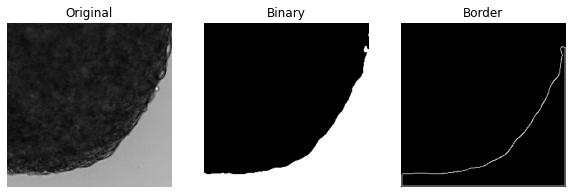

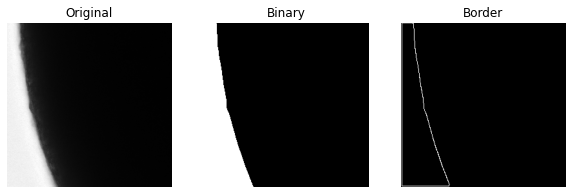

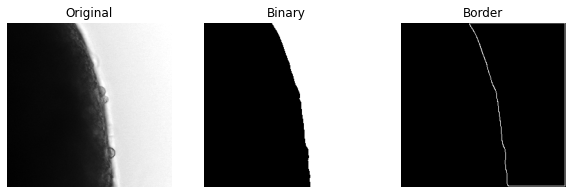

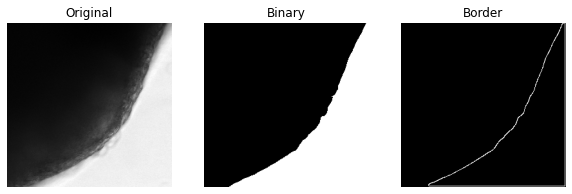

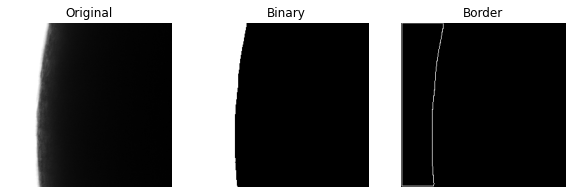

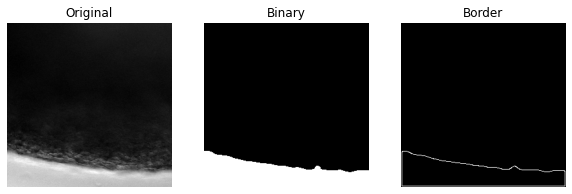

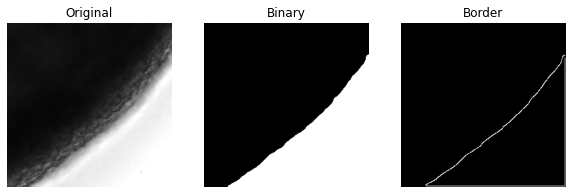

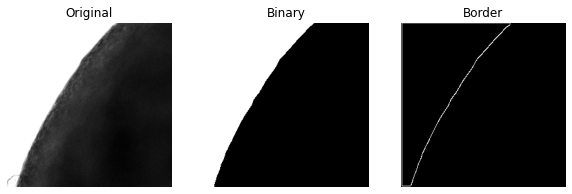

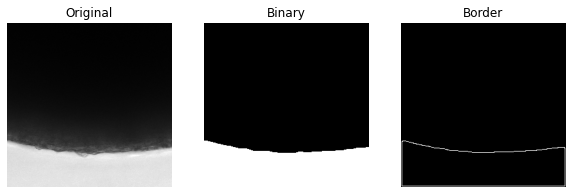

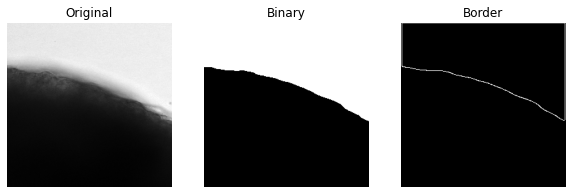

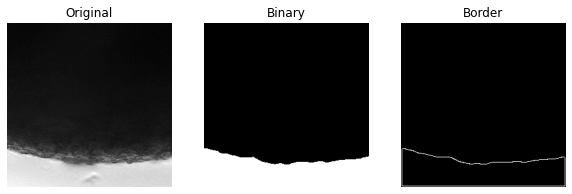

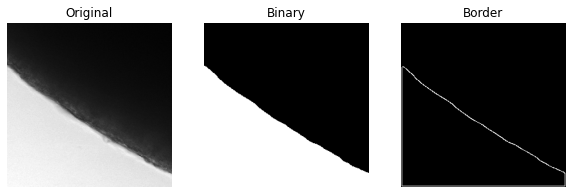

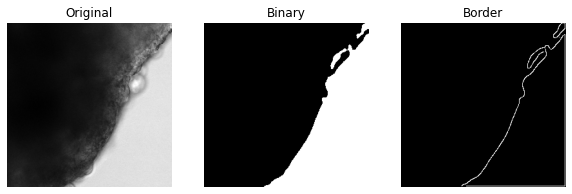

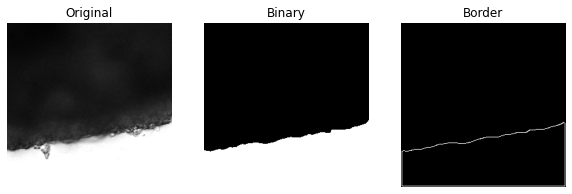

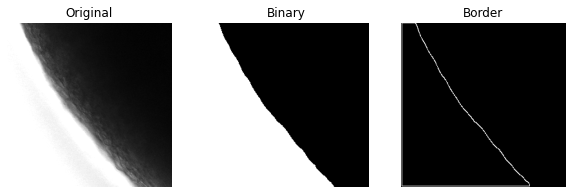

In [69]:
for file in files:
    slice_id = 0
    img = tifffile.imread(os.path.join(filepath, file))
    img_slice = img[slice_id,:,:]
    
    img_smooth = gaussian(img_slice, 2)
    thresh = threshold_otsu(img_smooth)
    image_thresh = img_smooth > thresh
    image_thresh = (1 - binary_fill_holes(1-image_thresh)).astype(bool)
    edges = feature.canny(image_thresh, 3)
    
    fig, ax = plt.subplots(1,3, figsize=(10,30))
    #fig.suptitle(file)
    ax[0].imshow(img_slice, cmap='gray')
    ax[0].title.set_text('Original')
    ax[0].axis('off')
    ax[1].imshow(image_thresh, cmap='gray')
    ax[1].title.set_text('Binary')
    ax[1].axis('off')
    ax[2].imshow(edges, cmap='gray')
    ax[2].title.set_text('Border')
    ax[2].axis('off')

## Find out how many points are on border

Be careful to run cell below as it takes a considerable amount of time!

In [ ]:
num_pixel_edges = []
for file in files:
    img = tifffile.imread(os.path.join(filepath, file))
    for slice_id in range(img.shape[0]):
        img_slice = img[slice_id,:,:]
        edges_slice = extract_border(img_slice)
        num_pixel_edges.append(np.sum(edges_slice))

In [48]:
num_pixel_edges = np.array(num_pixel_edges)
print('Average number of pixels on border: ', np.mean(num_pixel_edges))
print('Std of border pixels: ', np.std(num_pixel_edges))

Average number of pixels on border:  764.3885613768185
Std of border pixels:  210.0780320763817


# Open an example video and work with that

## Lets try with tracking ten points along the border

Opening file: Strong contraction.lif - O1464_2a.tif
Number of frames in video:  1208


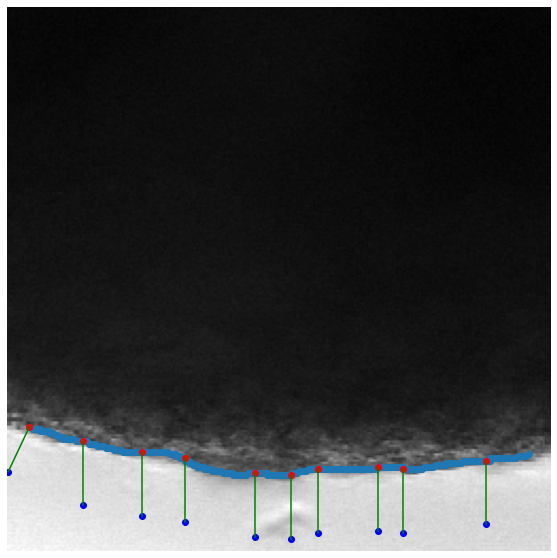

In [194]:
example_file = files[10]

print('Opening file:' , example_file)
vid = tifffile.imread(os.path.join(filepath, example_file))
print('Number of frames in video: ', vid.shape[0])
border_points, track_points, static_points = get_tracking_points(vid[0])

plt.figure(figsize=(10,10))
plt.imshow(vid[0], cmap='gray')
plt.axis('off')
plt.scatter(border_points[1],border_points[0])
plt.scatter(track_points[1], track_points[0], c='r')
plt.scatter(static_points[1], static_points[0], c='b')
for i in range(len(static_points[0])): 
    plt.plot((track_points[1][i], static_points[1][i]), (track_points[0][i], static_points[0][i]), c='g')


# Signal Extraction

In [195]:
distances, points_lost = track_points_in_vid(vid, track_points, static_points, view=True, wait=20) # view video and set frame rate
print('Done! Points lost during tracking: ', points_lost)

Done! Points lost during tracking:  6


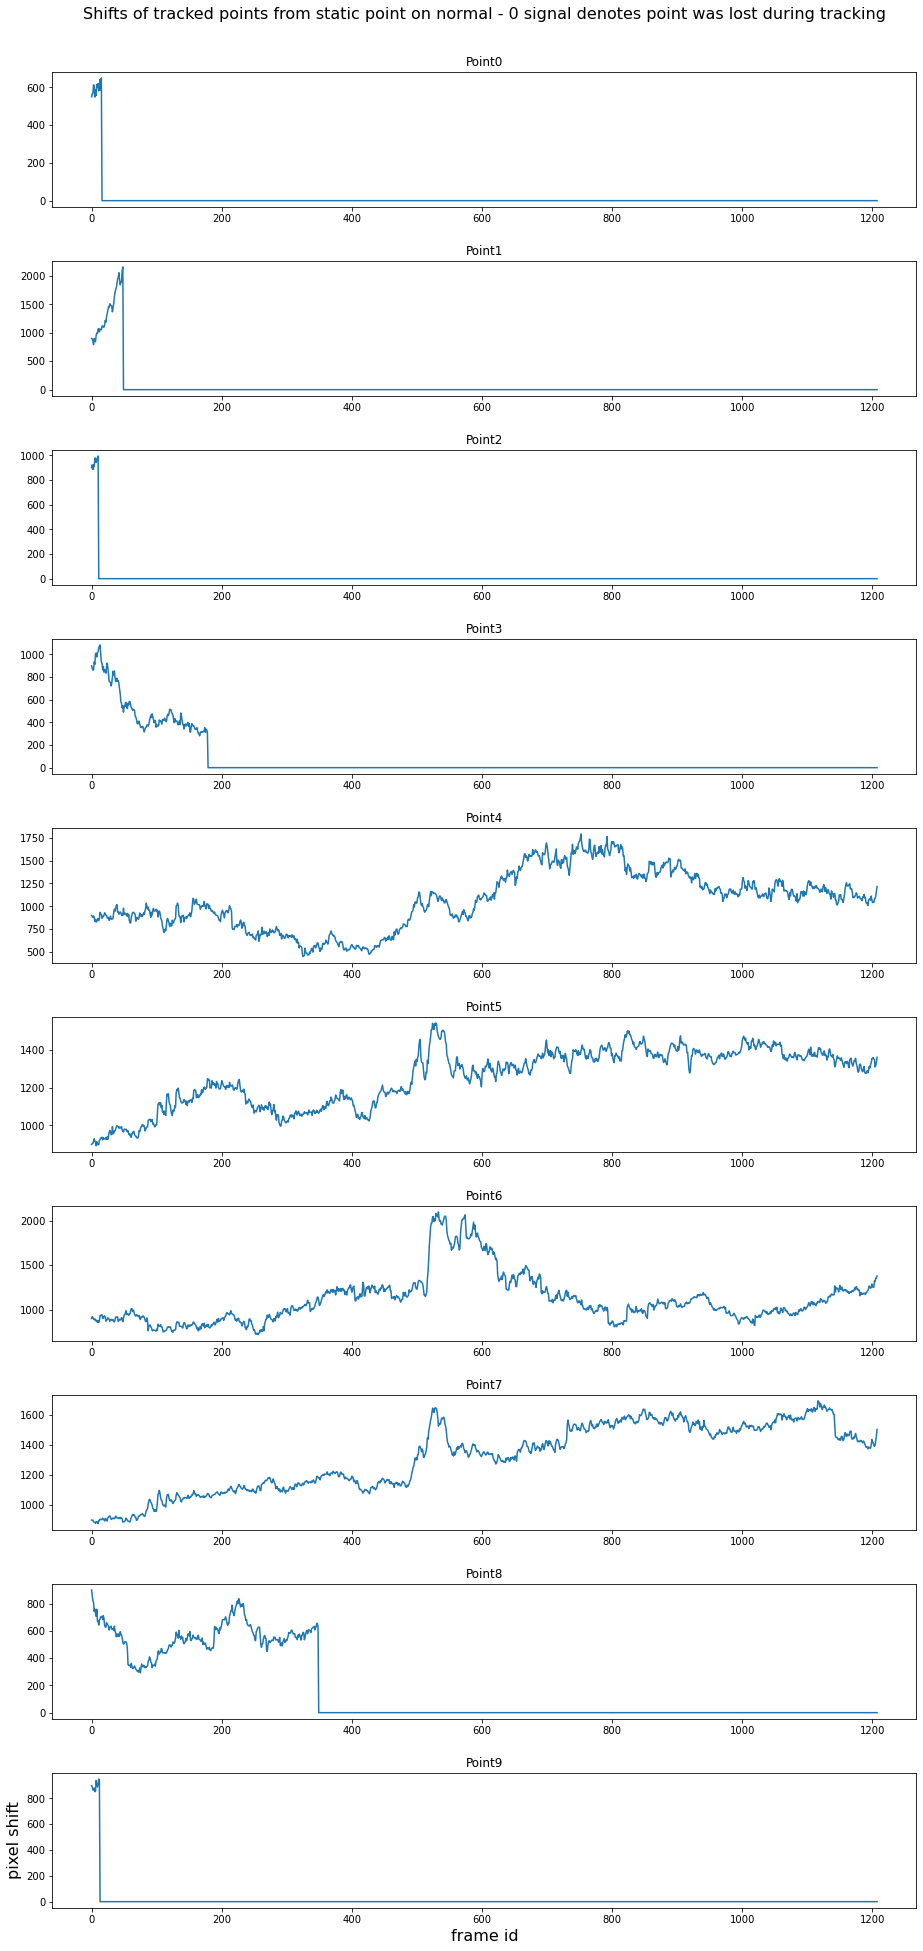

In [214]:
fig, ax = plt.subplots(10, figsize=(15,30))
fig.suptitle('Shifts of tracked points from static point on normal - 0 signal denotes point was lost during tracking', fontsize=16)
for i in range(10):
    ax[i].plot(np.arange(distances.shape[1]), distances[i,:])
    ax[i].set_title('Point'+str(i))
plt.xlabel('frame id', fontsize=16)
plt.ylabel('pixel shift', fontsize=16)
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.95, 
                    wspace=0.4, 
                    hspace=0.4)


## Optional - save distance plots as numpy arrays

In [217]:
new_file = example_file.split('.')[0]+'.npy'
np.save(new_file, distances)

# Extract signals for all videos

In [ ]:
for file in files:
    print('Opening file:' , example_file)
    vid = tifffile.imread(os.path.join(filepath, file))
    border_points, track_points, static_points = get_tracking_points(vid[0])
    distances, points_lost = track_points_in_vid(vid, track_points, static_points, view=True, wait=20) # view video and set frame rate
    new_file = file.split('.')[0]+'.npy'
    np.save(new_file, distances)
